# 导入包，设定随机数种子

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import collections

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123)

# 定义分类名称

In [2]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# 下载数据集

In [3]:
from torchvision import datasets, transforms
data_path = '../data-unversioned/p1ch6/'
cifar10 = datasets.CIFAR10(
    data_path, train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

100%|██████████| 170M/170M [00:15<00:00, 11.2MB/s] 


In [4]:
cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

In [5]:
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])
          for img, label in cifar10
          if label in [0, 2]]
cifar2_val = [(img, label_map[label])
              for img, label in cifar10_val
              if label in [0, 2]]

# 搭建一个简单的全连接网络

一个全连接网络。

In [6]:
connected_model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2))

打印参数信息。

In [7]:
numel_list = [p.numel()
              for p in connected_model.parameters()
              if p.requires_grad == True]
sum(numel_list), numel_list

(3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])

使用 Softmax 输出分类的全连接网络。

In [8]:
first_model = nn.Sequential(
                nn.Linear(3072, 512),
                nn.Tanh(),
                nn.Linear(512, 2),
                nn.LogSoftmax(dim=1))

In [9]:
numel_list = [p.numel() for p in first_model.parameters()]
sum(numel_list), numel_list

(1574402, [1572864, 512, 1024, 2])

## 更多模块定义
线性层。

In [10]:
linear = nn.Linear(3072, 1024)

linear.weight.shape, linear.bias.shape

(torch.Size([1024, 3072]), torch.Size([1024]))

卷积层。

In [11]:
conv = nn.Conv2d(3, 16, kernel_size=3) # <1>
conv

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [12]:
conv.weight.shape, conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

# 查看数据：图片 cifar2

In [13]:
img, _ = cifar2[0
# 对图片进行了卷积操作
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

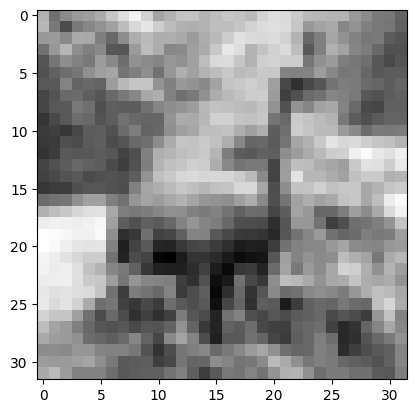

In [14]:
plt.imshow(img.mean(0), cmap='gray')
plt.show()

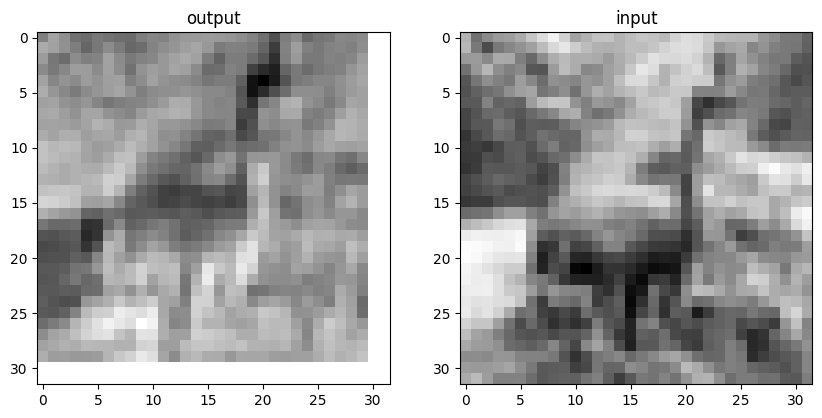

In [15]:
plt.figure(figsize=(10, 4.8))  # bookskip
ax1 = plt.subplot(1, 2, 1)   # bookskip
plt.title('output')   # bookskip
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  # bookskip
plt.imshow(img.mean(0), cmap='gray')  # bookskip
plt.title('input')  # bookskip
plt.savefig('Ch8_F2_PyTorch.png')  # bookskip
plt.show()

In [16]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1) # <1>
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

In [17]:
with torch.no_grad():
    conv.bias.zero_()
    
with torch.no_grad():
    conv.weight.fill_(1.0 / 9.0)

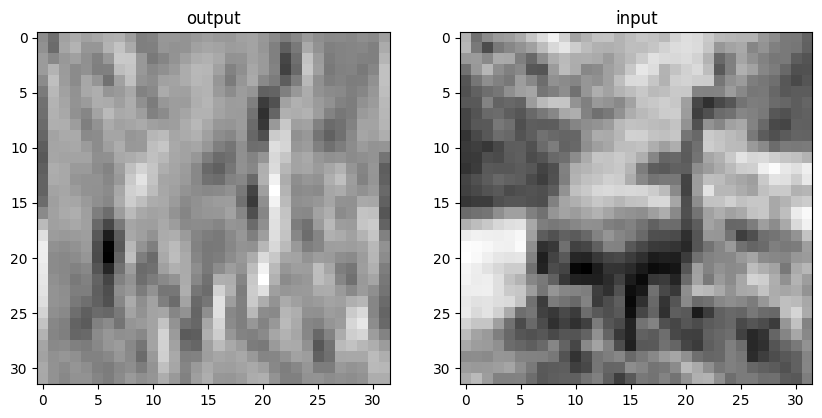

In [64]:
output = conv(img.unsqueeze(0))
plt.figure(figsize=(10, 4.8))  # bookskip
ax1 = plt.subplot(1, 2, 1)   # bookskip
plt.title('output')   # bookskip
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  # bookskip
plt.imshow(img.mean(0), cmap='gray')  # bookskip
plt.title('input')  # bookskip
plt.savefig('Ch8_F4_PyTorch.png')  # bookskip
plt.show()

In [19]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)

with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0]])
    conv.bias.zero_()

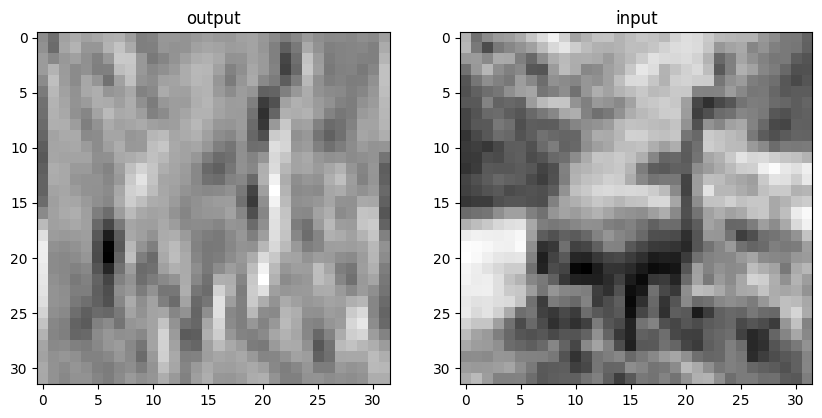

In [20]:
output = conv(img.unsqueeze(0))
plt.figure(figsize=(10, 4.8))  # bookskip
ax1 = plt.subplot(1, 2, 1)   # bookskip
plt.title('output')   # bookskip
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  # bookskip
plt.imshow(img.mean(0), cmap='gray')  # bookskip
plt.title('input')  # bookskip
plt.savefig('Ch8_F5_PyTorch.png')  # bookskip
plt.show()

In [21]:
pool = nn.MaxPool2d(2)
output = pool(img.unsqueeze(0))

img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 3, 16, 16]))

# Model 定义

In [22]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            # ...
            )

In [65]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(8 * 8 * 8, 32),
            nn.Tanh(),
            nn.Linear(32, 2))

In [66]:
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

## Print model info

In [67]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Conv2d: 1-1                            448
├─Tanh: 1-2                              --
├─MaxPool2d: 1-3                         --
├─Conv2d: 1-4                            1,160
├─Tanh: 1-5                              --
├─MaxPool2d: 1-6                         --
├─Flatten: 1-7                           --
├─Linear: 1-8                            16,416
├─Tanh: 1-9                              --
├─Linear: 1-10                           66
Total params: 18,090
Trainable params: 18,090
Non-trainable params: 0

In [29]:
model(img.unsqueeze(0))

tensor([[-0.0936, -0.0037]], grad_fn=<AddmmBackward0>)

使用类的形式定义 Model.

In [30]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8 * 8 * 8) # <1>
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

In [31]:
model = Net()

numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [32]:
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [33]:
model = Net()
model(img.unsqueeze(0))

tensor([[-0.1309, -0.1730]], grad_fn=<AddmmBackward0>)

# 定义训练迭代
## 在 CPU 上执行训练

In [35]:
import datetime  # <1>

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):  # <2>
        loss_train = 0.0
        for imgs , labels in train_loader:  # <3>  Batch, 批处理，比如 imgs 代表 30 张图片，而不是一张图片
            
            outputs = model(imgs)  # <4>
            
            loss = loss_fn(outputs, labels)  # <5>

            optimizer.zero_grad()  # <6>
            
            loss.backward()  # <7>
            
            optimizer.step()  # <8>

            loss_train += loss.item()  # <9>

        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader)))  # <10>

加载训练数据，和超参数，优化器，损失函数

In [36]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)  # <1>

model = Net()  #  <2>
optimizer = optim.SGD(model.parameters(), lr=1e-2)  #  <3>
loss_fn = nn.CrossEntropyLoss()  #  <4>

training_loop(  # <5>
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

2026-04-17 11:56:02.085141 Epoch 1, Training loss 0.6204580966454403
2026-04-17 11:56:12.687370 Epoch 10, Training loss 0.3409512461560547
2026-04-17 11:56:24.965158 Epoch 20, Training loss 0.30159971184411627
2026-04-17 11:56:37.506576 Epoch 30, Training loss 0.2755791086489987
2026-04-17 11:56:50.109709 Epoch 40, Training loss 0.2556997612118721
2026-04-17 11:57:02.178351 Epoch 50, Training loss 0.23590444137526165
2026-04-17 11:57:13.840757 Epoch 60, Training loss 0.22033958478718046
2026-04-17 11:57:25.711975 Epoch 70, Training loss 0.20418963457938213
2026-04-17 11:57:37.996221 Epoch 80, Training loss 0.19059595342274685
2026-04-17 11:57:50.519810 Epoch 90, Training loss 0.17630188470813118
2026-04-17 11:58:02.810093 Epoch 100, Training loss 0.16392898426693717


In [37]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():  # <1>
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1) # <2>
                total += labels.shape[0]  # <3>
                correct += int((predicted == labels).sum())  # <4>

        print("Accuracy {}: {:.2f}".format(name , correct / total))

validate(model, train_loader, val_loader)

Accuracy train: 0.93
Accuracy val: 0.90


## 保存模型

In [38]:
torch.save(model.state_dict(), data_path + 'birds_vs_airplanes.pt')

## 加载模型

In [39]:
loaded_model = Net()  # <1>
loaded_model.load_state_dict(torch.load(data_path
                                        + 'birds_vs_airplanes.pt'))

<All keys matched successfully>

## 在 CPU 上训练

In [40]:
device = (torch.device('cuda') if torch.cuda.is_available()
          else torch.device('cpu'))
print(f"Training on device {device}.")

Training on device cuda.


In [41]:
import datetime

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)  # <1>
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.item()

        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader)))

In [42]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = Net().to(device=device)  # <1>
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

2026-04-17 11:58:55.427311 Epoch 1, Training loss 0.6064609023416119
2026-04-17 11:58:58.656513 Epoch 10, Training loss 0.33065685962036157
2026-04-17 11:59:02.095701 Epoch 20, Training loss 0.29236207513292883
2026-04-17 11:59:05.568942 Epoch 30, Training loss 0.26794022117640565
2026-04-17 11:59:08.896902 Epoch 40, Training loss 0.24256380889446114
2026-04-17 11:59:12.085104 Epoch 50, Training loss 0.22405029012329258
2026-04-17 11:59:15.365673 Epoch 60, Training loss 0.20989297468001675
2026-04-17 11:59:18.937298 Epoch 70, Training loss 0.19378194590188136
2026-04-17 11:59:22.284756 Epoch 80, Training loss 0.18061180531409135
2026-04-17 11:59:25.689582 Epoch 90, Training loss 0.16813654585438928
2026-04-17 11:59:29.234740 Epoch 100, Training loss 0.15467344680029876


In [43]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)
all_acc_dict = collections.OrderedDict()

def validate(model, train_loader, val_loader):
    accdict = {}
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device=device)
                labels = labels.to(device=device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1) # <1>
                total += labels.shape[0]
                correct += int((predicted == labels).sum())

        print("Accuracy {}: {:.2f}".format(name , correct / total))
        accdict[name] = correct / total
    return accdict

all_acc_dict["baseline"] = validate(model, train_loader, val_loader)

Accuracy train: 0.94
Accuracy val: 0.90


In [44]:
loaded_model = Net().to(device=device)
loaded_model.load_state_dict(torch.load(data_path
                                        + 'birds_vs_airplanes.pt',
                                        map_location=device))

<All keys matched successfully>

In [45]:
class NetWidth(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 16 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [46]:
model = NetWidth().to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

validate(model, train_loader, val_loader)

2026-04-17 11:59:43.557372 Epoch 1, Training loss 0.5435327099766701
2026-04-17 11:59:47.862458 Epoch 10, Training loss 0.31995731725054943
2026-04-17 11:59:52.548681 Epoch 20, Training loss 0.277971840255959
2026-04-17 11:59:57.027662 Epoch 30, Training loss 0.24681613954958642
2026-04-17 12:00:01.556102 Epoch 40, Training loss 0.21948836293000323
2026-04-17 12:00:06.441437 Epoch 50, Training loss 0.19397652595286158
2026-04-17 12:00:10.907210 Epoch 60, Training loss 0.1709815187818685
2026-04-17 12:00:15.424996 Epoch 70, Training loss 0.14995419393014756
2026-04-17 12:00:19.921532 Epoch 80, Training loss 0.12999743415386814
2026-04-17 12:00:24.641032 Epoch 90, Training loss 0.11160425005397599
2026-04-17 12:00:29.196066 Epoch 100, Training loss 0.0949078752143178
Accuracy train: 0.95
Accuracy val: 0.90


{'train': 0.952, 'val': 0.901}

In [47]:
class NetWidth(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out


In [48]:
model = NetWidth(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

all_acc_dict["width"] = validate(model, train_loader, val_loader)

2026-04-17 12:00:36.723502 Epoch 1, Training loss 0.5513146749347638
2026-04-17 12:00:40.824945 Epoch 10, Training loss 0.31592100925126654
2026-04-17 12:00:45.385921 Epoch 20, Training loss 0.2729548651511502
2026-04-17 12:00:49.925521 Epoch 30, Training loss 0.24379919431391794
2026-04-17 12:00:54.435610 Epoch 40, Training loss 0.2176130789860039
2026-04-17 12:00:58.937310 Epoch 50, Training loss 0.19250054273066247
2026-04-17 12:01:03.637119 Epoch 60, Training loss 0.1683542549040667
2026-04-17 12:01:08.082095 Epoch 70, Training loss 0.14541708170228704
2026-04-17 12:01:12.557194 Epoch 80, Training loss 0.12407281261625563
2026-04-17 12:01:17.011220 Epoch 90, Training loss 0.10424769829934949
2026-04-17 12:01:21.491752 Epoch 100, Training loss 0.0863001126273992
Accuracy train: 0.97
Accuracy val: 0.90


In [49]:
sum(p.numel() for p in model.parameters())

38386

In [50]:
def training_loop_l2reg(n_epochs, optimizer, model, loss_fn,
                        train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            l2_lambda = 0.001
            l2_norm = sum(p.pow(2.0).sum()
                          for p in model.parameters())  # <1>
            loss = loss + l2_lambda * l2_norm

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_train += loss.item()
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader)))


In [51]:
model = Net().to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop_l2reg(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["l2 reg"] = validate(model, train_loader, val_loader)

2026-04-17 12:01:31.100058 Epoch 1, Training loss 0.5791277243832874
2026-04-17 12:01:36.163605 Epoch 10, Training loss 0.35910173282501806
2026-04-17 12:01:41.880875 Epoch 20, Training loss 0.3215483561822563
2026-04-17 12:01:50.017204 Epoch 30, Training loss 0.301909797985083
2026-04-17 12:01:58.303744 Epoch 40, Training loss 0.28549914346758726
2026-04-17 12:02:07.038934 Epoch 50, Training loss 0.27188152511408376
2026-04-17 12:02:15.618188 Epoch 60, Training loss 0.26007762076748403
2026-04-17 12:02:22.373968 Epoch 70, Training loss 0.2490796331007769
2026-04-17 12:02:27.777351 Epoch 80, Training loss 0.23846361306822225
2026-04-17 12:02:32.663155 Epoch 90, Training loss 0.22814344657454522
2026-04-17 12:02:37.837049 Epoch 100, Training loss 0.21818103850077672
Accuracy train: 0.92
Accuracy val: 0.89


In [52]:
class NetDropout(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p=0.4)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.conv2_dropout = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = self.conv1_dropout(out)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = self.conv2_dropout(out)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [53]:
model = NetDropout(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["dropout"] = validate(model, train_loader, val_loader)

2026-04-17 12:02:47.688448 Epoch 1, Training loss 0.5702681628761778
2026-04-17 12:02:51.991493 Epoch 10, Training loss 0.37895456402544764
2026-04-17 12:02:56.699018 Epoch 20, Training loss 0.3540058331504749
2026-04-17 12:03:01.377910 Epoch 30, Training loss 0.32597520112232037
2026-04-17 12:03:06.181579 Epoch 40, Training loss 0.31337310762921716
2026-04-17 12:03:10.866299 Epoch 50, Training loss 0.2993969284235292
2026-04-17 12:03:15.528841 Epoch 60, Training loss 0.28841038892982873
2026-04-17 12:03:20.302164 Epoch 70, Training loss 0.280399229496148
2026-04-17 12:03:25.002034 Epoch 80, Training loss 0.26505215437548935
2026-04-17 12:03:29.688180 Epoch 90, Training loss 0.25889074413260077
2026-04-17 12:03:34.355151 Epoch 100, Training loss 0.24622765107519307
Accuracy train: 0.90
Accuracy val: 0.87


In [54]:
class NetBatchNorm(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_batchnorm = nn.BatchNorm2d(num_features=n_chans1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, 
                               padding=1)
        self.conv2_batchnorm = nn.BatchNorm2d(num_features=n_chans1 // 2)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = self.conv1_batchnorm(self.conv1(x))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = self.conv2_batchnorm(self.conv2(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [55]:
model = NetBatchNorm(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["batch_norm"] = validate(model, train_loader, val_loader)

2026-04-17 12:04:57.947028 Epoch 1, Training loss 0.49715064931067693
2026-04-17 12:05:03.369072 Epoch 10, Training loss 0.27422238696532647
2026-04-17 12:05:09.100082 Epoch 20, Training loss 0.2125609939929786
2026-04-17 12:05:14.881765 Epoch 30, Training loss 0.16657830323952777
2026-04-17 12:05:20.616606 Epoch 40, Training loss 0.12477858528305011
2026-04-17 12:05:26.384592 Epoch 50, Training loss 0.08807671948033534
2026-04-17 12:05:32.102926 Epoch 60, Training loss 0.06018759202283279
2026-04-17 12:05:37.814196 Epoch 70, Training loss 0.038692279795932163
2026-04-17 12:05:43.506368 Epoch 80, Training loss 0.025587841396807295
2026-04-17 12:05:49.329998 Epoch 90, Training loss 0.019334770009443638
2026-04-17 12:05:55.130933 Epoch 100, Training loss 0.012696072601588669
Accuracy train: 0.99
Accuracy val: 0.89


In [56]:
class NetDepth(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.conv3 = nn.Conv2d(n_chans1 // 2, n_chans1 // 2,
                               kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out = F.max_pool2d(torch.relu(self.conv3(out)), 2)
        out = out.view(-1, 4 * 4 * self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [57]:
model = NetDepth(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["depth"] = validate(model, train_loader, val_loader)

2026-04-17 12:06:02.636613 Epoch 1, Training loss 0.6815529256869274
2026-04-17 12:06:06.976737 Epoch 10, Training loss 0.34761176633227403
2026-04-17 12:06:11.737019 Epoch 20, Training loss 0.3026720993458086
2026-04-17 12:06:16.509885 Epoch 30, Training loss 0.27354572039500924
2026-04-17 12:06:21.390110 Epoch 40, Training loss 0.24476614129391444
2026-04-17 12:06:26.294798 Epoch 50, Training loss 0.21596642080575798
2026-04-17 12:06:31.652238 Epoch 60, Training loss 0.1889461939027355
2026-04-17 12:06:36.759936 Epoch 70, Training loss 0.1630765368841636
2026-04-17 12:06:41.806267 Epoch 80, Training loss 0.13827241477882787
2026-04-17 12:06:46.839285 Epoch 90, Training loss 0.11368002913370254
2026-04-17 12:06:52.045278 Epoch 100, Training loss 0.09034616285401165
Accuracy train: 0.94
Accuracy val: 0.90


In [58]:
class NetRes(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.conv3 = nn.Conv2d(n_chans1 // 2, n_chans1 // 2,
                               kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out1 = out
        out = F.max_pool2d(torch.relu(self.conv3(out)) + out1, 2)
        out = out.view(-1, 4 * 4 * self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [59]:
model = NetRes(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["res"] = validate(model, train_loader, val_loader)

2026-04-17 12:08:31.832777 Epoch 1, Training loss 0.6160409752350704
2026-04-17 12:08:36.728656 Epoch 10, Training loss 0.3320038361344368
2026-04-17 12:08:41.773317 Epoch 20, Training loss 0.2915230932509064
2026-04-17 12:08:46.824101 Epoch 30, Training loss 0.2595878417135044
2026-04-17 12:08:52.194898 Epoch 40, Training loss 0.229902897765682
2026-04-17 12:08:57.252063 Epoch 50, Training loss 0.20310672956287482
2026-04-17 12:09:02.210129 Epoch 60, Training loss 0.1754975709945533
2026-04-17 12:09:07.264636 Epoch 70, Training loss 0.1480989810197976
2026-04-17 12:09:12.254809 Epoch 80, Training loss 0.12116777678583837
2026-04-17 12:09:17.091963 Epoch 90, Training loss 0.09469662161816837
2026-04-17 12:09:21.912315 Epoch 100, Training loss 0.07026862657990805
Accuracy train: 0.96
Accuracy val: 0.90


In [60]:
class ResBlock(nn.Module):
    def __init__(self, n_chans):
        super(ResBlock, self).__init__()
        self.conv = nn.Conv2d(n_chans, n_chans, kernel_size=3,
                              padding=1, bias=False)  # <1>
        self.batch_norm = nn.BatchNorm2d(num_features=n_chans)
        torch.nn.init.kaiming_normal_(self.conv.weight,
                                      nonlinearity='relu')  # <2>
        torch.nn.init.constant_(self.batch_norm.weight, 0.5)
        torch.nn.init.zeros_(self.batch_norm.bias)

    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = torch.relu(out)
        return out + x

In [61]:
class NetResDeep(nn.Module):
    def __init__(self, n_chans1=32, n_blocks=10):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.resblocks = nn.Sequential(
            *(n_blocks * [ResBlock(n_chans=n_chans1)]))
        self.fc1 = nn.Linear(8 * 8 * n_chans1, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = self.resblocks(out)
        out = F.max_pool2d(out, 2)
        out = out.view(-1, 8 * 8 * self.n_chans1)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out
    


In [62]:
model = NetResDeep(n_chans1=32, n_blocks=100).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["res deep"] = validate(model, train_loader, val_loader)

2026-04-17 12:09:47.239337 Epoch 1, Training loss 2.7101132547020153
2026-04-17 12:12:14.549557 Epoch 10, Training loss 0.35382249059191173
2026-04-17 12:14:58.489951 Epoch 20, Training loss 0.27872141251328647
2026-04-17 12:17:42.526080 Epoch 30, Training loss 0.22829258256846932
2026-04-17 12:20:26.767235 Epoch 40, Training loss 0.19303266590188264
2026-04-17 12:23:10.706574 Epoch 50, Training loss 0.1543868637293767
2026-04-17 12:25:54.614940 Epoch 60, Training loss 0.12732736501771552
2026-04-17 12:28:38.976686 Epoch 70, Training loss 0.1211011606108421
2026-04-17 12:31:22.967738 Epoch 80, Training loss 0.08456225276800097
2026-04-17 12:34:07.072727 Epoch 90, Training loss 0.0660251956966937
2026-04-17 12:36:50.949838 Epoch 100, Training loss 0.05246944294554318
Accuracy train: 0.87
Accuracy val: 0.76


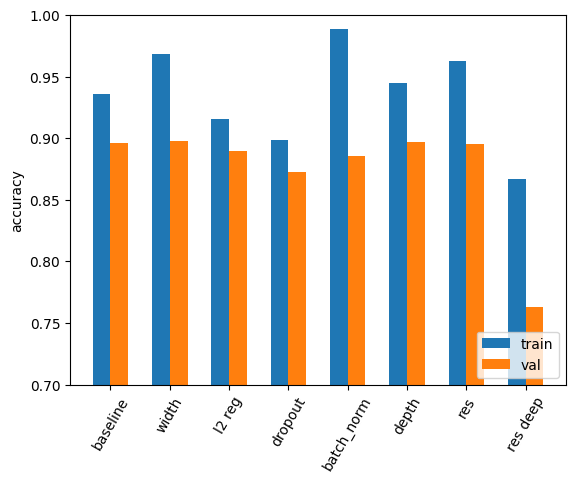

In [63]:
trn_acc = [v['train'] for k, v in all_acc_dict.items()]
val_acc = [v['val'] for k, v in all_acc_dict.items()]

width =0.3
plt.bar(np.arange(len(trn_acc)), trn_acc, width=width, label='train')
plt.bar(np.arange(len(val_acc))+ width, val_acc, width=width, label='val')
plt.xticks(np.arange(len(val_acc))+ width/2, list(all_acc_dict.keys()),
           rotation=60)
plt.ylabel('accuracy')
plt.legend(loc='lower right')
plt.ylim(0.7, 1)
plt.savefig('accuracy_comparison.png', bbox_inches='tight')
plt.show()
